# Analyze Model Comparison Experiment Results

This notebook analyzes results from prompt experiments comparing different LLM models.

**Features:**
- Load and compare results from multiple models
- Visualize agreement/disagreement patterns
- Analyze cost vs. performance tradeoffs
- Explore specific disagreement cases

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import sys

# Add project root to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent))

from experiments.compare_models.core.registry import CallTypeRegistry
from experiments.compare_models.handlers import *

# Configure plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports complete")

/Users/abuonomo/Library/Caches/pypoetry/virtualenvs/paper-data-linking-GXZ7GlHC-py3.10/lib/python3.10/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'fields' has been removed
  warnings.warn(message, UserWarning)


✓ Imports complete


## 1. Load Experiment Results

In [2]:
# Configure experiment to analyze
# EXPERIMENT_NAME = "test_pipeline_validation"
EXPERIMENT_NAME = "full_comparison_20251029" 
EXPERIMENT_DIR = Path("prompt_experiments") / EXPERIMENT_NAME

print(f"Analyzing experiment: {EXPERIMENT_NAME}")
print(f"Directory: {EXPERIMENT_DIR}")
print()

# Find all result files
result_files = sorted(EXPERIMENT_DIR.glob("*.jsonl"))
print(f"Found {len(result_files)} result files:")
for f in result_files:
    print(f"  - {f.name}")

Analyzing experiment: full_comparison_20251029
Directory: prompt_experiments/full_comparison_20251029

Found 30 result files:
  - openai_gpt-5-mini_20251029_152905.jsonl
  - openai_gpt-5-mini_20251029_161613.jsonl
  - openai_gpt-5-mini_20251029_191829.jsonl
  - openai_gpt-5-mini_20251030_091739.jsonl
  - openai_gpt-5-mini_20251030_135730.jsonl
  - openai_gpt-5-mini_20251030_154534.jsonl
  - openai_gpt-5-mini_20251031_005953.jsonl
  - openai_gpt-5-mini_20251031_022817.jsonl
  - openai_gpt-5-mini_20251031_094333.jsonl
  - openai_gpt-5-mini_20251031_103639.jsonl
  - openai_gpt-5-nano_20251029_151649.jsonl
  - openai_gpt-5-nano_20251029_160829.jsonl
  - openai_gpt-5-nano_20251029_172919.jsonl
  - openai_gpt-5-nano_20251030_015811.jsonl
  - openai_gpt-5-nano_20251030_134402.jsonl
  - openai_gpt-5-nano_20251030_145816.jsonl
  - openai_gpt-5-nano_20251030_194803.jsonl
  - openai_gpt-5-nano_20251031_020307.jsonl
  - openai_gpt-5-nano_20251031_092034.jsonl
  - openai_gpt-5-nano_20251031_102655.

In [3]:
def load_jsonl(file_path):
    """Load JSONL file into list of dicts."""
    results = []
    with open(file_path) as f:
        for line in f:
            if line.strip():
                results.append(json.loads(line))
    return results

# Load all results
all_results = {}
for result_file in result_files:
    # Extract model name from filename
    model_name = result_file.stem.rsplit('_', 2)[0]  # Remove timestamp
    all_results[model_name] = load_jsonl(result_file)
    print(f"Loaded {len(all_results[model_name])} results for {model_name}")

print(f"\nTotal models: {len(all_results)}")

Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 98 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-mini
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 98 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5-nano
Loaded 100 results for openai_gpt-5
Loaded 100 results for openai_gpt-5
Loaded 100 results for openai_gpt-5
Loaded 98 results for openai_gpt-5
Loaded 100 results for openai_gpt-5
Loa

## 2. Cost and Performance Overview

In [4]:
# Calculate aggregate statistics per model
stats = []
for model_name, results in all_results.items():
    total_cost = sum(r.get('estimated_cost_usd', 0) for r in results)
    total_tokens = sum(r.get('total_tokens', 0) for r in results)
    avg_duration = sum(r.get('duration_ms', 0) for r in results if r.get('duration_ms')) / len(results)
    success_count = sum(1 for r in results if 'error' not in r)
    
    stats.append({
        'Model': model_name,
        'Cases': len(results),
        'Success Rate': f"{success_count}/{len(results)}",
        'Total Cost': f"${total_cost:.6f}",
        'Avg Cost/Case': f"${total_cost/len(results):.6f}",
        'Total Tokens': f"{total_tokens:,}",
        'Avg Tokens/Case': f"{int(total_tokens/len(results)):,}",
        'Avg Duration (ms)': f"{int(avg_duration):,}"
    })

stats_df = pd.DataFrame(stats)
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
display(stats_df)


MODEL PERFORMANCE SUMMARY


,Model,Cases,Success Rate,Total Cost,Avg Cost/Case,Total Tokens,Avg Tokens/Case,Avg Duration (ms)
0,openai_gpt-5-mini,100,100/100,$0.066664,$0.000667,"112,335","1,123","5,838"
1,openai_gpt-5-nano,100,100/100,$0.036168,$0.000362,"169,424","1,694","8,580"
2,openai_gpt-5,100,100/100,$0.621521,$0.006215,"141,155","1,411","11,309"


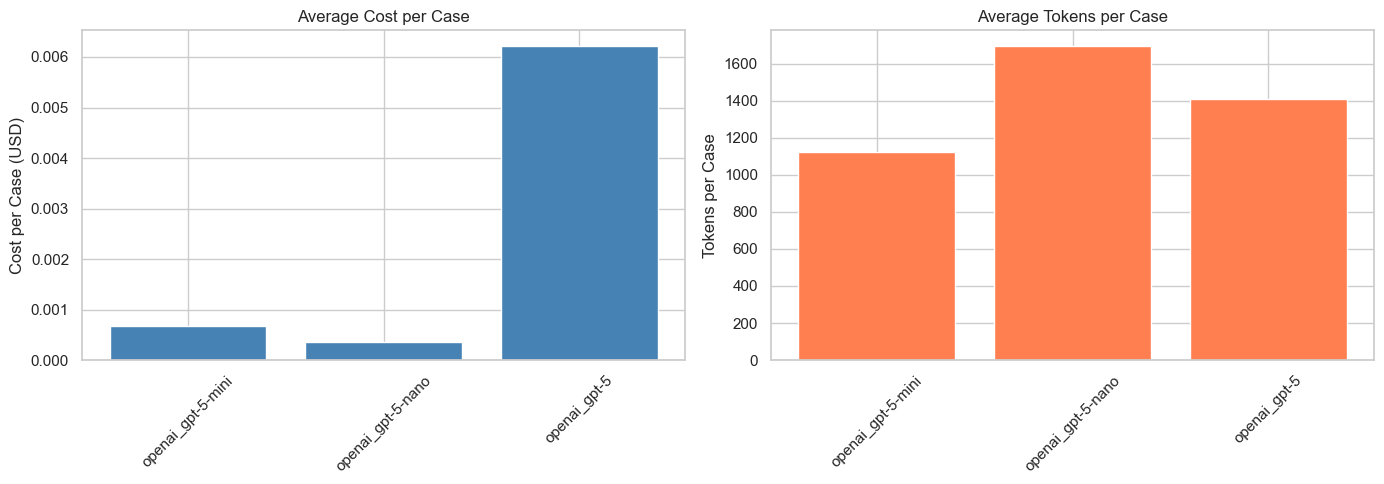

In [5]:
# Visualize cost comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost per case
cost_data = [(model, sum(r.get('estimated_cost_usd', 0) for r in results) / len(results)) 
             for model, results in all_results.items()]
models, costs = zip(*cost_data)
axes[0].bar(models, costs, color='steelblue')
axes[0].set_ylabel('Cost per Case (USD)')
axes[0].set_title('Average Cost per Case')
axes[0].tick_params(axis='x', rotation=45)

# Tokens per case
token_data = [(model, sum(r.get('total_tokens', 0) for r in results) / len(results)) 
              for model, results in all_results.items()]
models, tokens = zip(*token_data)
axes[1].bar(models, tokens, color='coral')
axes[1].set_ylabel('Tokens per Case')
axes[1].set_title('Average Tokens per Case')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Response Comparison Analysis

In [6]:
# Get handler for this call type
if all_results:
    first_result = next(iter(all_results.values()))[0]
    call_type = first_result['call_type']
    handler = CallTypeRegistry.get(call_type)
    print(f"Call type: {call_type}")
    print(f"Handler: {handler.__class__.__name__}")
else:
    print("No results loaded")

Call type: mission_selection
Handler: MissionSelectionHandler


In [7]:
# Compare responses across models (pairwise)
def compare_all_models(all_results, handler):
    """Compare all model pairs and track agreements."""
    model_names = list(all_results.keys())
    
    if len(model_names) < 2:
        print("Need at least 2 models to compare")
        return None
    
    # Create comparison matrix
    comparisons = []
    
    for i, model1 in enumerate(model_names):
        for model2 in model_names[i+1:]:
            results1 = all_results[model1]
            results2 = all_results[model2]
            
            # Align by case_index
            agreements = 0
            disagreements = 0
            disagreement_cases = []
            
            for r1 in results1:
                case_idx = r1['case_index']
                r2 = next((r for r in results2 if r['case_index'] == case_idx), None)
                
                if r2 is None:
                    continue
                
                parsed1 = r1.get('parsed_response')
                parsed2 = r2.get('parsed_response')
                
                comparison = handler.compare_responses(parsed1, parsed2)
                
                if comparison.agree:
                    agreements += 1
                else:
                    disagreements += 1
                    disagreement_cases.append({
                        'case_index': case_idx,
                        'original_id': r1.get('original_id'),
                        'model1_response': parsed1,
                        'model2_response': parsed2,
                        'model1_summary': handler.get_short_summary(parsed1),
                        'model2_summary': handler.get_short_summary(parsed2),
                        'details': comparison.details
                    })
            
            total = agreements + disagreements
            agreement_rate = agreements / total if total > 0 else 0
            
            comparisons.append({
                'Model 1': model1,
                'Model 2': model2,
                'Agreements': agreements,
                'Disagreements': disagreements,
                'Agreement Rate': f"{agreement_rate:.1%}",
                'disagreement_cases': disagreement_cases
            })
    
    return pd.DataFrame(comparisons)

comparison_df = compare_all_models(all_results, handler)

if comparison_df is not None:
    print("\n" + "="*80)
    print("PAIRWISE MODEL COMPARISONS")
    print("="*80)
    display(comparison_df[['Model 1', 'Model 2', 'Agreements', 'Disagreements', 'Agreement Rate']])


PAIRWISE MODEL COMPARISONS


,Model 1,Model 2,Agreements,Disagreements,Agreement Rate
0,openai_gpt-5-mini,openai_gpt-5-nano,81,19,81.0%
1,openai_gpt-5-mini,openai_gpt-5,85,15,85.0%
2,openai_gpt-5-nano,openai_gpt-5,81,19,81.0%


## 4. Disagreement Analysis

In [8]:
# Show all disagreements for first comparison pair
if comparison_df is not None and len(comparison_df) > 0:
    first_comparison = comparison_df.iloc[0]
    disagreements = first_comparison['disagreement_cases']
    
    print(f"\n{'='*80}")
    print(f"DISAGREEMENTS: {first_comparison['Model 1']} vs {first_comparison['Model 2']}")
    print(f"{'='*80}\n")
    
    if disagreements:
        for i, d in enumerate(disagreements, 1):
            print(f"\nCase {d['case_index']} (ID: {d['original_id'][:8]}...)")
            print(f"  {first_comparison['Model 1']}: {d['model1_summary']}")
            print(f"  {first_comparison['Model 2']}: {d['model2_summary']}")
            if d.get('details'):
                print(f"  Details: {d['details']}")
            print()
    else:
        print("No disagreements found!")
else:
    print("No comparisons available")


DISAGREEMENTS: openai_gpt-5-mini vs openai_gpt-5-nano


Case 1 (ID: c1ef0e4a...)
  openai_gpt-5-mini: 1
  openai_gpt-5-nano: 1,2
  Details: Response 1: [1] | Response 2: [1, 2] | Exact match: False | Top-1 match: True | Overlap: {1} | Jaccard similarity: 0.50


Case 12 (ID: d1dcbd44...)
  openai_gpt-5-mini: 1
  openai_gpt-5-nano: AMBIGUOUS
  Details: Response 1: [1] | Response 2: [0] | Exact match: False | Top-1 match: False | Overlap: none | Jaccard similarity: 0.00


Case 21 (ID: 39880385...)
  openai_gpt-5-mini: AMBIGUOUS
  openai_gpt-5-nano: 1
  Details: Response 1: [0] | Response 2: [1] | Exact match: False | Top-1 match: False | Overlap: none | Jaccard similarity: 0.00


Case 28 (ID: 145dd844...)
  openai_gpt-5-mini: 0,1
  openai_gpt-5-nano: AMBIGUOUS
  Details: Response 1: [0, 1] | Response 2: [0] | Exact match: False | Top-1 match: True | Overlap: {0} | Jaccard similarity: 0.50


Case 37 (ID: 2ca03373...)
  openai_gpt-5-mini: AMBIGUOUS
  openai_gpt-5-nano: 0,1,10
  Details: Re

## 5. Deep Dive: Inspect Specific Case

In [9]:
# Select a case to examine in detail
CASE_INDEX = 1  # Change this to explore different cases

print(f"\n{'='*80}")
print(f"CASE {CASE_INDEX} - DETAILED VIEW")
print(f"{'='*80}\n")

for model_name, results in all_results.items():
    case = next((r for r in results if r['case_index'] == CASE_INDEX), None)
    
    if case:
        print(f"\n{model_name.upper()}")
        print("-" * 80)
        
        # Show user prompt (truncated)
        user_msg = next((m['content'] for m in case['input_messages'] if m['role'] == 'user'), None)
        if user_msg:
            print(f"\nUser Prompt (first 500 chars):")
            # print(user_msg[:500] + "..." if len(user_msg) > 500 else user_msg)
            print(user_msg)
        
        # Show raw output
        print(f"\nRaw Output:")
        print(case.get('output_content', 'N/A'))
        
        # Show parsed response
        print(f"\nParsed Response:")
        print(json.dumps(case.get('parsed_response'), indent=2))
        
        # Show cost/tokens
        print(f"\nMetrics:")
        print(f"  Cost: ${case.get('estimated_cost_usd', 0):.6f}")
        print(f"  Tokens: {case.get('total_tokens', 0):,} (prompt: {case.get('prompt_tokens', 0)}, completion: {case.get('completion_tokens', 0)})")
        print(f"  Duration: {case.get('duration_ms', 0):,} ms")
        print()


CASE 1 - DETAILED VIEW


OPENAI_GPT-5-MINI
--------------------------------------------------------------------------------

User Prompt (first 500 chars):
<mission_selection_task>
  <instrument_description>
    Instrument: Solar Ultraviolet Imager (SUVI) on board GOES
Context: SUVI provided extended-field EUV imaging of the middle corona during a dedicated off-pointing campaign, enabling direct observation of coronal web dynamics and their relation to slow solar wind outflows. The study primarily used the 195 Å passband, with additional context from 171 Å.
Time period 1: 2018-08-07 to 2018-09-13
Additional info 1: "The resulting images have a field of view out to about 5R☉, at an image scale of 5″ pixel-1, and a cadence of around 20 minutes."
  </instrument_description>

  <candidate_missions>
    1. GOES16 (Geostationary Operational Environmental Satellite (GOES-R) Series 16)
2. GOES17 (Geostationary Operational Environmental Satellite (GOES-R) Series 17)
  </candidate_missions>

  

In [10]:
# Better side-by-side comparison for structure_analysis
CASE_TO_COMPARE = 1  # Change this

print(f"\n{'='*80}")
print(f"SIDE-BY-SIDE COMPARISON - CASE {CASE_TO_COMPARE}")
print(f"{'='*80}\n")

model_names = list(all_results.keys())
if len(model_names) >= 2:
    # Get both model results
    case1 = next((r for r in all_results[model_names[0]] if r['case_index'] == CASE_TO_COMPARE), None)
    case2 = next((r for r in all_results[model_names[1]] if r['case_index'] == CASE_TO_COMPARE), None)
    
    if case1 and case2:
        output1 = json.loads(case1['output_content'])
        output2 = json.loads(case2['output_content'])
        
        # Create comparison DataFrame
        comparison_data = []
        
        # Get all unique instrument names from both
        names1 = set(inst['name'] for inst in output1.get('instruments', []))
        names2 = set(inst['name'] for inst in output2.get('instruments', []))
        all_names = sorted(names1 | names2)
        
        print(f"Model 1 ({model_names[0]}): {len(output1['instruments'])} instruments, {sum(len(i.get('data_collection_periods', [])) for i in output1['instruments'])} periods")
        print(f"Model 2 ({model_names[1]}): {len(output2['instruments'])} instruments, {sum(len(i.get('data_collection_periods', [])) for i in output2['instruments'])} periods")
        print()
        
        # Build comparison table
        for name in all_names:
            inst1 = next((i for i in output1['instruments'] if i['name'] == name), None)
            inst2 = next((i for i in output2['instruments'] if i['name'] == name), None)
            
            comparison_data.append({
                'Instrument': name[:60] + '...' if len(name) > 60 else name,
                model_names[0]: f"✓ ({len(inst1.get('data_collection_periods', []))} periods)" if inst1 else "✗ Missing",
                model_names[1]: f"✓ ({len(inst2.get('data_collection_periods', []))} periods)" if inst2 else "✗ Missing"
            })
        
        df_comp = pd.DataFrame(comparison_data)
        display(df_comp)
        
        # Show which instruments were missed
        only_in_1 = names1 - names2
        only_in_2 = names2 - names1
        
        if only_in_1:
            print(f"\n⚠️  Only in {model_names[0]}:")
            for name in only_in_1:
                print(f"  - {name}")
        
        if only_in_2:
            print(f"\n⚠️  Only in {model_names[1]}:")
            for name in only_in_2:
                print(f"  - {name}")
        
        if not only_in_1 and not only_in_2:
            print("\n✓ Both models found the same instrument names")
    else:
        print("Case not found in results")
else:
    print("Need at least 2 models for comparison")


SIDE-BY-SIDE COMPARISON - CASE 1



JSONDecodeError: Extra data: line 1 column 2 (char 1)

## 5A. Better Side-by-Side Comparison

Compare model outputs in a more readable format:

## 6. Response Distribution Analysis

In [11]:
# Analyze distribution of different response types
def analyze_response_distribution(results, handler):
    """Analyze what types of responses each model produces."""
    summaries = []
    for r in results:
        parsed = r.get('parsed_response')
        summary = handler.get_short_summary(parsed)
        summaries.append(summary)
    
    from collections import Counter
    return Counter(summaries)

print(f"\n{'='*80}")
print("RESPONSE DISTRIBUTION BY MODEL")
print(f"{'='*80}\n")

for model_name, results in all_results.items():
    dist = analyze_response_distribution(results, handler)
    print(f"\n{model_name}:")
    for response_type, count in dist.most_common():
        print(f"  {response_type}: {count} ({count/len(results):.1%})")


RESPONSE DISTRIBUTION BY MODEL


openai_gpt-5-mini:
  1: 74 (74.0%)
  AMBIGUOUS: 22 (22.0%)
  0,1: 1 (1.0%)
  0,9,12: 1 (1.0%)
  0,9,1998,2004: 1 (1.0%)
  1,2: 1 (1.0%)

openai_gpt-5-nano:
  1: 72 (72.0%)
  AMBIGUOUS: 21 (21.0%)
  4: 2 (2.0%)
  1,2: 1 (1.0%)
  0,1,10: 1 (1.0%)
  7: 1 (1.0%)
  0,1,2: 1 (1.0%)
  3: 1 (1.0%)

openai_gpt-5:
  1: 63 (63.0%)
  AMBIGUOUS: 31 (31.0%)
  2: 2 (2.0%)
  1,5,6: 1 (1.0%)
  1,2,3: 1 (1.0%)
  3: 1 (1.0%)
  1,2: 1 (1.0%)


## 7. Cost vs Performance Scatter

In [ ]:
# Scatter plot: cost vs agreement rate with baseline model
if len(all_results) >= 2:
    # Use first model as baseline
    baseline_model = list(all_results.keys())[0]
    baseline_results = all_results[baseline_model]
    
    scatter_data = []
    
    for model_name, results in all_results.items():
        if model_name == baseline_model:
            continue
        
        # Calculate agreement with baseline
        agreements = 0
        total = 0
        
        for r1 in baseline_results:
            case_idx = r1['case_index']
            r2 = next((r for r in results if r['case_index'] == case_idx), None)
            
            if r2 is None:
                continue
            
            parsed1 = r1.get('parsed_response')
            parsed2 = r2.get('parsed_response')
            
            comparison = handler.compare_responses(parsed1, parsed2)
            total += 1
            if comparison.agree:
                agreements += 1
        
        agreement_rate = agreements / total if total > 0 else 0
        avg_cost = sum(r.get('estimated_cost_usd', 0) for r in results) / len(results)
        
        scatter_data.append({
            'model': model_name,
            'cost': avg_cost,
            'agreement_rate': agreement_rate
        })
    
    if scatter_data:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for d in scatter_data:
            ax.scatter(d['cost'], d['agreement_rate'], s=200, alpha=0.6)
            ax.annotate(d['model'], (d['cost'], d['agreement_rate']), 
                       xytext=(5, 5), textcoords='offset points')
        
        ax.set_xlabel('Average Cost per Case (USD)')
        ax.set_ylabel(f'Agreement Rate with {baseline_model}')
        ax.set_title('Cost vs Agreement with Baseline Model')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("Need at least 2 models for comparison")

## 8. Export Disagreements for Further Analysis

In [ ]:
# Export disagreements to JSON for external analysis
if comparison_df is not None and len(comparison_df) > 0:
    output_file = EXPERIMENT_DIR / "disagreements_analysis.json"
    
    export_data = {
        'experiment_name': EXPERIMENT_NAME,
        'call_type': call_type,
        'comparisons': []
    }
    
    for _, row in comparison_df.iterrows():
        export_data['comparisons'].append({
            'model1': row['Model 1'],
            'model2': row['Model 2'],
            'agreements': row['Agreements'],
            'disagreements': row['Disagreements'],
            'agreement_rate': row['Agreement Rate'],
            'disagreement_cases': row['disagreement_cases']
        })
    
    with open(output_file, 'w') as f:
        json.dump(export_data, f, indent=2)
    
    print(f"\n✓ Exported disagreements to: {output_file}")
else:
    print("No comparisons to export")

## 9. Interactive Exploration

Use the cells below to explore specific aspects of your data:

In [ ]:
# Your custom analysis here
# Example: Look at a specific model's results

MODEL_TO_EXPLORE = "openai_gpt-5-nano"  # Change this

if MODEL_TO_EXPLORE in all_results:
    results = all_results[MODEL_TO_EXPLORE]
    print(f"Exploring {MODEL_TO_EXPLORE}")
    print(f"Total cases: {len(results)}")
    
    # Add your custom analysis here
    # e.g., filter by specific criteria, look at outliers, etc.
else:
    print(f"Model {MODEL_TO_EXPLORE} not found")
    print(f"Available models: {list(all_results.keys())}")